# More ways to create state for LangGraph
We are going to illustrate 3 ways to create state for LangGraph:
1. **typing.TypedDict**
2. **dataclasses.dataclass**
3. **pydantic.BaseModel**

## create state by typing.TypedDict

In [1]:
from typing import TypedDict, Literal

class TypedDictState(TypedDict):
    name: str
    game:Literal["cricket","badminton"]

In [2]:
def play_game(state:TypedDictState):
    print("---Play Game node has been called--")
    return {"name":state['name'] + " want to play "}

def cricket(state:TypedDictState):
    print("-- Cricket node has been called--")
    return {"name":state["name"] + " cricket","game":"cricket"}

def badminton(state:TypedDictState):
    print("-- badminton node has been called--")
    return {"name":state["name"] + " badminton","game":"badminton"}

In [3]:
import random
def decide_play(state:TypedDictState)->Literal["cricket","badminton"]:
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:
        return "cricket"
    else:
        return "badminton"

In [4]:
from langgraph.graph import StateGraph, START, END

builder=StateGraph(TypedDictState)
builder.add_node("playgame",play_game)
builder.add_node("cricket",cricket)
builder.add_node("badminton",badminton)

## Flow of the graph

builder.add_edge(START,"playgame")
builder.add_conditional_edges("playgame",decide_play)
builder.add_edge("cricket",END)
builder.add_edge("badminton",END)

# Add
graph = builder.compile()

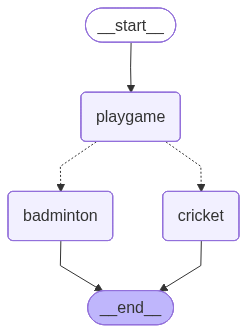

In [5]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
graph.invoke({"name":"Krish"})

---Play Game node has been called--
-- badminton node has been called--


{'name': 'Krish want to play  badminton', 'game': 'badminton'}

In [8]:
### input by integer 

graph.invoke({"name":123})

---Play Game node has been called--


TypeError: unsupported operand type(s) for +: 'int' and 'str'

## create state by dataclasses.dataclass

In [17]:
from dataclasses import dataclass
from typing import Literal

@dataclass
class DataClassState:
    name: str
    game:Literal["cricket","badminton"]

In [18]:
def play_game(state:DataClassState):
    print("---Play Game node has been called--")
    return {"name":state.name + " want to play "}

def cricket(state:DataClassState):
    print("-- Cricket node has been called--")
    return {"name":state.name + " cricket","game":"cricket"}

def badminton(state:DataClassState):
    print("-- badminton node has been called--")
    return {"name":state.name + " badminton","game":"badminton"}

In [19]:
def decide_play(state:DataclassState)->Literal["cricket","badminton"]:
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:
        return "cricket"
    else:
        return "badminton"

In [20]:
from langgraph.graph import StateGraph, START, END

builder=StateGraph(DataclassState)
builder.add_node("playgame",play_game)
builder.add_node("cricket",cricket)
builder.add_node("badminton",badminton)

## Flow of the graph

builder.add_edge(START,"playgame")
builder.add_conditional_edges("playgame",decide_play)
builder.add_edge("cricket",END)
builder.add_edge("badminton",END)

# Add
graph = builder.compile()

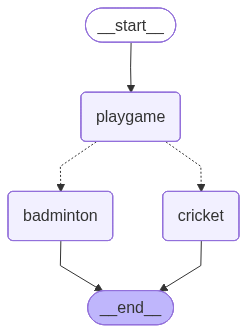

In [21]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
graph.invoke(DataClassState(name="KRish",game="cricket"))

---Play Game node has been called--
-- badminton node has been called--


{'name': 'KRish want to play  badminton', 'game': 'badminton'}

In [24]:
graph.invoke(DataClassState(name=123,game=456))

---Play Game node has been called--


TypeError: unsupported operand type(s) for +: 'int' and 'str'

## Create state by pydantic.BaseModel

In [26]:
from pydantic import BaseModel
from typing import Literal

class BaseModelState(BaseModel):
    name: str
    game:Literal["cricket","badminton"]

In [27]:
def play_game(state:BaseModelState):
    print("---Play Game node has been called--")
    return {"name":state.name + " want to play "}

def cricket(state:BaseModelState):
    print("-- Cricket node has been called--")
    return {"name":state.name + " cricket","game":"cricket"}

def badminton(state:BaseModelState):
    print("-- badminton node has been called--")
    return {"name":state.name + " badminton","game":"badminton"}

In [28]:
def decide_play(state:BaseModelState)->Literal["cricket","badminton"]:
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:
        return "cricket"
    else:
        return "badminton"

In [33]:
from langgraph.graph import StateGraph, START, END

builder=StateGraph(BaseModelState)
builder.add_node("playgame",play_game)
builder.add_node("cricket",cricket)
builder.add_node("badminton",badminton)

## Flow of the graph

builder.add_edge(START,"playgame")
builder.add_conditional_edges("playgame",decide_play)
builder.add_edge("cricket",END)
builder.add_edge("badminton",END)

# Add
graph = builder.compile()

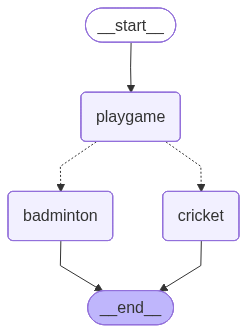

In [34]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
graph.invoke({"name":"KRish", "game":"cricket"})

---Play Game node has been called--
-- badminton node has been called--


{'name': 'KRish want to play  badminton', 'game': 'badminton'}

In [37]:
graph.invoke({"name":123, "game":456})

ValidationError: 2 validation errors for BaseModelState
name
  Input should be a valid string [type=string_type, input_value=123, input_type=int]
    For further information visit https://errors.pydantic.dev/2.11/v/string_type
game
  Input should be 'cricket' or 'badminton' [type=literal_error, input_value=456, input_type=int]
    For further information visit https://errors.pydantic.dev/2.11/v/literal_error